<a href="https://colab.research.google.com/github/tanusattri/Crypto-Trade-Data-Analysis/blob/main/Crypto_Trade_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [53]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

In [54]:
#data preparation
#load datasets and documentation
fear_greed_df= pd.read_csv('/content/fear_greed_index.csv')
historical_df= pd.read_csv('/content/historical_data.csv',on_bad_lines='skip', low_memory= False)
def document_dataset(df, name):
  print(f"Documenting: {name}")
  print(f"Dimensions: {df.shape[0]} rows and {df.shape[1]} columns")
  print(f"Missing values:{df.isnull().sum()}")
  print(f"Duplicate rows: {df.duplicated().sum()}")
document_dataset(fear_greed_df,"Fear and Greed Index")
document_dataset(historical_df,"Historical Data")

Documenting: Fear and Greed Index
Dimensions: 2644 rows and 4 columns
Missing values:timestamp         0
value             0
classification    0
date              0
dtype: int64
Duplicate rows: 0
Documenting: Historical Data
Dimensions: 366635 rows and 16 columns
Missing values:Account              0
Coin                 0
Execution Price      1
Size Tokens          2
Size USD             2
Side                 2
Timestamp IST        7
Start Position       7
Direction           12
Closed PnL          15
Transaction Hash    18
Order ID            21
Crossed             23
Fee                 24
Trade ID            28
Timestamp           31
dtype: int64
Duplicate rows: 155407


In [55]:
#alignment and standardizing timestamps to Date objects
historical_df['Timestamp IST']= pd.to_datetime(historical_df['Timestamp IST'], dayfirst=True, format='mixed', errors='coerce')
historical_df['date']= historical_df['Timestamp IST'].dt.date
fear_greed_df['date']= pd.to_datetime(fear_greed_df['date']).dt.date
aligned_df= pd.merge(historical_df, fear_greed_df[['date','value','classification']], on='date', how='left')
print(aligned_df.head())

                                      Account  Coin Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107          7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107            7.98   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107          7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107          7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107          7.9894   

  Size Tokens Size USD Side       Timestamp IST Start Position Direction  \
0      986.87  7872.16  BUY 2024-12-02 22:50:00              0       Buy   
1          16   127.68  BUY 2024-12-02 22:50:00    986.5245955       Buy   
2      144.09  1150.63  BUY 2024-12-02 22:50:00    1002.518996       Buy   
3      142.98  1142.04  BUY 2024-12-02 22:50:00    1146.558564       Buy   
4        8.73    69.75  BUY 2024-12-02 22:50:00    1289.488521       Buy   

  Closed PnL                                   Transaction Hash     Order ID  \
0          0  0xec09451986a1874e3a98

In [56]:
#key metrics
#daily PnL per trader (or per account)
daily_pnl= historical_df.groupby(['Account','date'])['Closed PnL'].sum().reset_index()

#win rate and avg trade size
historical_df['Closed PnL'] = pd.to_numeric(historical_df['Closed PnL'], errors='coerce')
historical_df['Size USD'] = pd.to_numeric(historical_df['Size USD'], errors='coerce')
realized= historical_df[historical_df['Closed PnL']!=0].copy()
win_rate= (realized['Closed PnL']>0).mean()*100
avg_size= historical_df['Size USD'].mean()

#long/short ratio
buys= historical_df[historical_df['Side'].str.upper()=='BUY'].shape[0]
sells= historical_df[historical_df['Side'].str.upper()=='SELL'].shape[0]
ls_ratio= buys/sells if sells> 0 else 0

#number of trades per day
trades_per_day= historical_df.groupby('date').size().reset_index(name='Trade Count')

#outputs
print("Analysis Results")
print(f"Total trades analyzed:{len(historical_df)}")
print(f"Overall Win Rate: {win_rate: .2f}%")
print(f"Average Trade Size: ${avg_size: .2f}")
print(f"Long/Short Ratio: {ls_ratio: .2f}")
print(daily_pnl.head())

Analysis Results
Total trades analyzed:366635
Overall Win Rate:  82.45%
Average Trade Size: $ 6101761655.98
Long/Short Ratio:  0.94
                                      Account        date  \
0  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-11   
1  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-17   
2  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-18   
3  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-22   
4  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-26   

                                          Closed PnL  
0  0000000000000000000000000000000000000000000000...  
1  0000000000000000000000000000000000000000000000...  
2           0000000000000000000000000000000000000000  
3  -1274.766258-1666.425635-2445.435308-2263.2227...  
4  64.44462103.56026103.5602632.06232.0622.917642...  


In [57]:
#analysis
#performance analysis
def get_win_rate(x):
  realized= x[x!=0]
  return (realized>0).mean() if len(realized)>0 else 0
aligned_df['Closed PnL'] = pd.to_numeric(aligned_df['Closed PnL'], errors='coerce')
performance= aligned_df.groupby('classification').agg({'Closed PnL': ['sum','mean',get_win_rate]})
print("Performance by Sentiment:", performance)

Performance by Sentiment:                   Closed PnL                            
                         sum           mean get_win_rate
classification                                          
Extreme Fear    1.113734e+06      27.546543     0.763764
Extreme Greed   2.428107e+10  349669.852116     0.886517
Fear            4.852151e+06      44.460893     0.870594
Greed           7.443216e+10  893168.007169     0.752847
Neutral         1.504794e+06      23.415453     0.811119


In [58]:
#behavior analysis
#calculate long bias
aligned_df['is_buy']= aligned_df['Side'].str.upper().map({'BUY':1,'SELL':0})

# Ensure 'Size USD' is numeric in aligned_df before aggregation
aligned_df['Size USD'] = pd.to_numeric(aligned_df['Size USD'], errors='coerce')

#grouping behavior by sentiment classification
sentiment_behavior= aligned_df.groupby('classification').agg({
    'Size USD': 'mean',
    'is_buy': 'mean',
    'Account': 'count'
}).rename(columns={'is_buy':'Long Bias','Account':'Trade Count'})

#aggregate metrics per account
trader_segments= aligned_df.groupby('Account').agg({
    'Size USD': ['mean', 'max'],
    'date': 'nunique',
    'Closed PnL': [get_win_rate, 'sum','std']
})
trader_segments.columns= ['avg_size', 'max_size', 'days_active','win_rate','total_pnl','pnl_volatility']

#frequent vs infrequent
median_days= trader_segments['days_active'].median()
trader_segments['frequency']= np.where(trader_segments['days_active']> median_days, 'frequent', 'infrequent')

#high vs low leverage
size_threshold= trader_segments['max_size'].quantile(0.75)
trader_segments['Risk Profile']= np.where(trader_segments['max_size']> size_threshold, 'High Leverage/Size', 'Low Leverage/Size')

#consistency
trader_segments['Consistency']= np.where(
    (trader_segments['win_rate']>0.5) & (trader_segments['pnl_volatility']< trader_segments['pnl_volatility'].median()),
    'Consistent Winner','Inconsistent'
)
print("Trader Segmentation Summary:")
print(trader_segments[['frequency','Risk Profile','Consistency']].value_counts().head())

Trader Segmentation Summary:
frequency   Risk Profile        Consistency      
infrequent  Low Leverage/Size   Inconsistent         13
frequent    Low Leverage/Size   Inconsistent         12
                                Consistent Winner     8
infrequent  High Leverage/Size  Inconsistent          6
            Low Leverage/Size   Consistent Winner     5
Name: count, dtype: int64


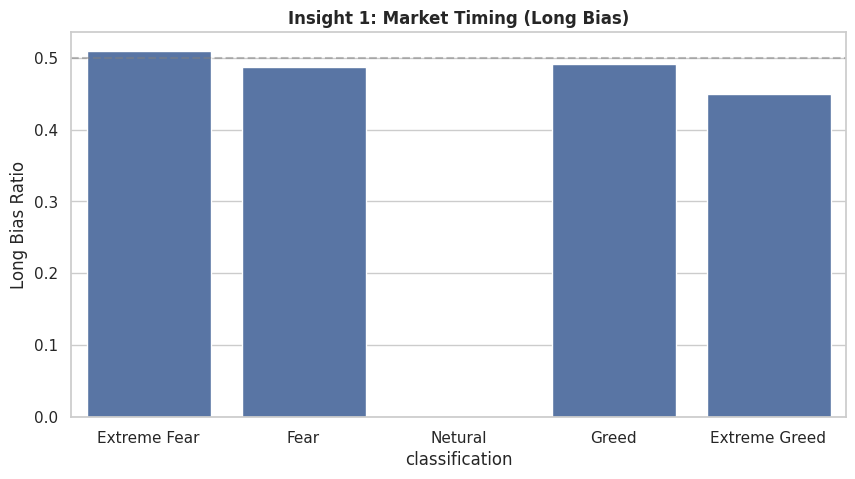

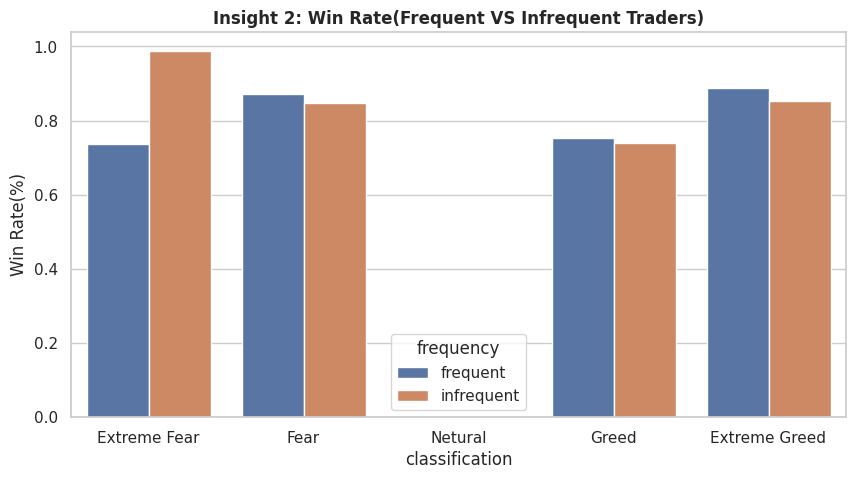

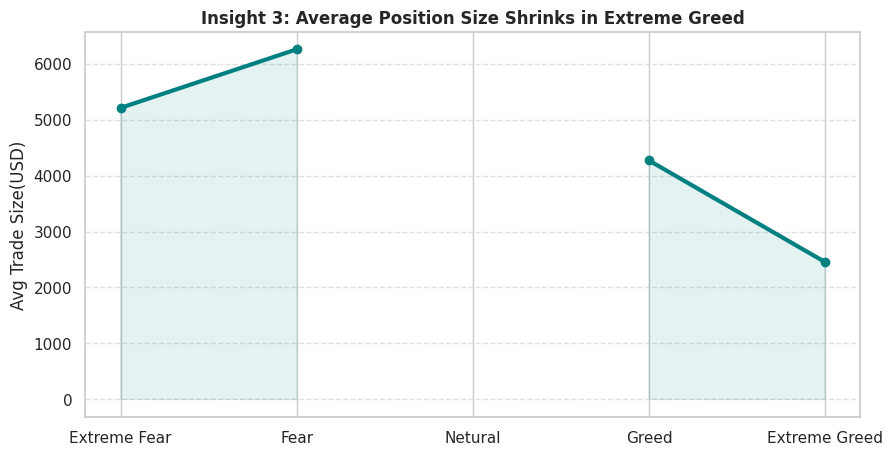

In [59]:
#insights
sns.set_theme(style='whitegrid')
sentiment_order= ['Extreme Fear','Fear','Neutral','Greed','Extreme Greed']
aligned_df = aligned_df.merge(trader_segments[['frequency']], on='Account', how='left')

#insight-1: market timing(long bias)
aligned_df['is_buy']= aligned_df['Side'].str.upper().map({'BUY':1, 'SELL':0})
long_bias= aligned_df.groupby('classification')['is_buy'].mean().reset_index()
plt.figure(figsize=(10,5))
sns.barplot(data=long_bias, x='classification',y='is_buy',order=sentiment_order)
plt.axhline(0.5, ls='--',color='gray',alpha=0.5)
plt.title('Insight 1: Market Timing (Long Bias)',fontweight='bold')
plt.ylabel('Long Bias Ratio')

#insight-2: segment durability(win rate)
def get_win_rate(x):
  closed= x[x!=0]
  return (closed>0).mean() if len(closed)>0 else 0
seg_win_rate= aligned_df.groupby(['classification', 'frequency'])['Closed PnL'].apply(get_win_rate).reset_index()
plt.figure(figsize=(10,5))
sns.barplot(data=seg_win_rate,x='classification',y='Closed PnL',hue='frequency',order=sentiment_order)
plt.title('Insight 2: Win Rate(Frequent VS Infrequent Traders)', fontweight='bold')
plt.ylabel('Win Rate(%)')

#insight-3: size vs sentiment(position splitting)
avg_size= aligned_df.groupby('classification')['Size USD'].mean().reindex(sentiment_order).reset_index()
plt.figure(figsize=(10,5))
plt.plot(avg_size['classification'],avg_size['Size USD'],marker='o',color='teal',linewidth=3)
plt.fill_between(avg_size['classification'],avg_size['Size USD'],alpha=0.1,color='teal')
plt.title('Insight 3: Average Position Size Shrinks in Extreme Greed',fontweight='bold')
plt.ylabel('Avg Trade Size(USD)')
plt.grid(True,axis='y',linestyle='--',alpha=0.6)

In [60]:
#group traders by behavior
trader_features= aligned_df.groupby('Account').agg({
    'Size USD':'mean',
    'Order ID':'count',
    'Closed PnL':lambda x: (x[x!=0]>0).mean(),
    'date':'nunique'
})
trader_features.columns= ['avg_size','trade_count','win_rate','days_active']

# Handle division by zero for trades_per_day
trader_features['trades_per_day'] = trader_features.apply(
    lambda row: row['trade_count'] / row['days_active'] if row['days_active'] > 0 else 0,
    axis=1
)

# Fill any remaining NaNs (e.g., from win_rate) before scaling
trader_features = trader_features.fillna(0)

#scale features and cluster
scaler= StandardScaler()
X_scaled= scaler.fit_transform(trader_features[['avg_size','trades_per_day','win_rate']])
kmeans= KMeans(n_clusters=3,random_state=42)
trader_features['Cluster']= kmeans.fit_predict(X_scaled)
archetypes= {0: "Scalper", 1:"Opportunist",2:"Whale"}
trader_features['Archetype']= trader_features['Cluster'].map(archetypes)
print(trader_features[['Archetype','avg_size','win_rate']].head())

#predictive model
daily= aligned_df.groupby(['date','Account']).agg({
    'value':'first',
    'is_buy':'mean',
    'Closed PnL': 'sum'
}).reset_index()
daily= daily.sort_values(['Account', 'date'])
daily['target']= (daily.groupby('Account')['Closed PnL'].shift(-1)>0).astype(int)
model_data = daily.dropna()

#train/test split
X= model_data[['value','is_buy','Closed PnL']]
y= model_data['target']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)

#random forest
model= RandomForestClassifier(n_estimators=100)
model.fit(X_train,y_train)
print(f"Next-Day Profit Prediction Accuracy:{model.score(X_test,y_test):.2%}")

                                           Archetype      avg_size  win_rate
Account                                                                     
-12-2024 07:30                               Scalper      0.000000  1.000000
0.005073                                       Whale      0.000000  0.000000
0x083384f897ee0f19899168e3b1bec365f52a9012   Scalper  16159.576734  0.792725
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd   Scalper   1567.653843  0.757361
0x271b280974205ca63b716753467d5a371de622ab   Scalper   8893.000898  0.715619
Next-Day Profit Prediction Accuracy:61.62%
